In [30]:
# import sys
# import os

# sys.path.append(os.path.abspath(".."))

In [31]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import nibabel as nib
import pandas as pd
import os

from constants_BHSD import *
from utils_BHSD import *

---
### Unlabel folder
---

In [32]:
print(UNLABEL_DIR)

/mnt/d/BHSD/unlabel_2000


In [33]:
unlabeled_path = os.path.join(DATASET_ROOT, UNLABEL_DIR)
files = os.listdir(unlabeled_path)
for file in files:
    print(file, ":" , len(os.listdir(os.path.join(unlabeled_path, file))))

anybleed : 562
nobleed : 1418


---
### Label folder
---

In [34]:
label_path = os.path.join(DATASET_ROOT, LABEL_DIR)
files = os.listdir(label_path)
for file in files:
    print(file, ":" , len(os.listdir(os.path.join(label_path, file))))

ground truths : 192
images : 192


In [35]:

unlabeled_path = os.path.join(DATASET_ROOT, UNLABEL_DIR)
rows = []

for folder in os.listdir(unlabeled_path):
    folder_path = os.path.join(unlabeled_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    # lấy định dạng file
    formats = set()

    for f in files:
        if f.endswith(".nii.gz"):
            formats.add(".nii.gz")
        else:
            formats.add(os.path.splitext(f)[1])

    rows.append({
        "folder": folder,
        "num_files": len(files),
        "file_formats": ", ".join(formats),
    })

df = pd.DataFrame(rows)

df

,folder,num_files,file_formats
0,anybleed,562,.nii.gz
1,nobleed,1418,.nii.gz


In [36]:

labeled_path = os.path.join(DATASET_ROOT, LABEL_DIR)
rows = []

for folder in os.listdir(labeled_path):
    folder_path = os.path.join(labeled_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    # lấy định dạng file
    formats = set()

    for f in files:
        if f.endswith(".nii.gz"):
            formats.add(".nii.gz")
        else:
            formats.add(os.path.splitext(f)[1])

    rows.append({
        "folder": folder,
        "num_files": len(files),
        "file_formats": ", ".join(formats),
    })

df = pd.DataFrame(rows)

df

,folder,num_files,file_formats
0,ground truths,192,.nii.gz
1,images,192,.nii.gz


In [37]:
file_path = os.path.join(labeled_path, "ground truths")
file = os.path.join(file_path, "ID_0b10cbee_ID_f91d6a7cd2.nii.gz")
nii_img = nib.load(file)
data = nii_img.get_fdata()
header = nii_img.header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 512 512  32   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         0.488281   0.488281   5.2284584  0.         0.
  0.         0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.0
quatern_c       : 0.9890158
quatern_d       : 0.147

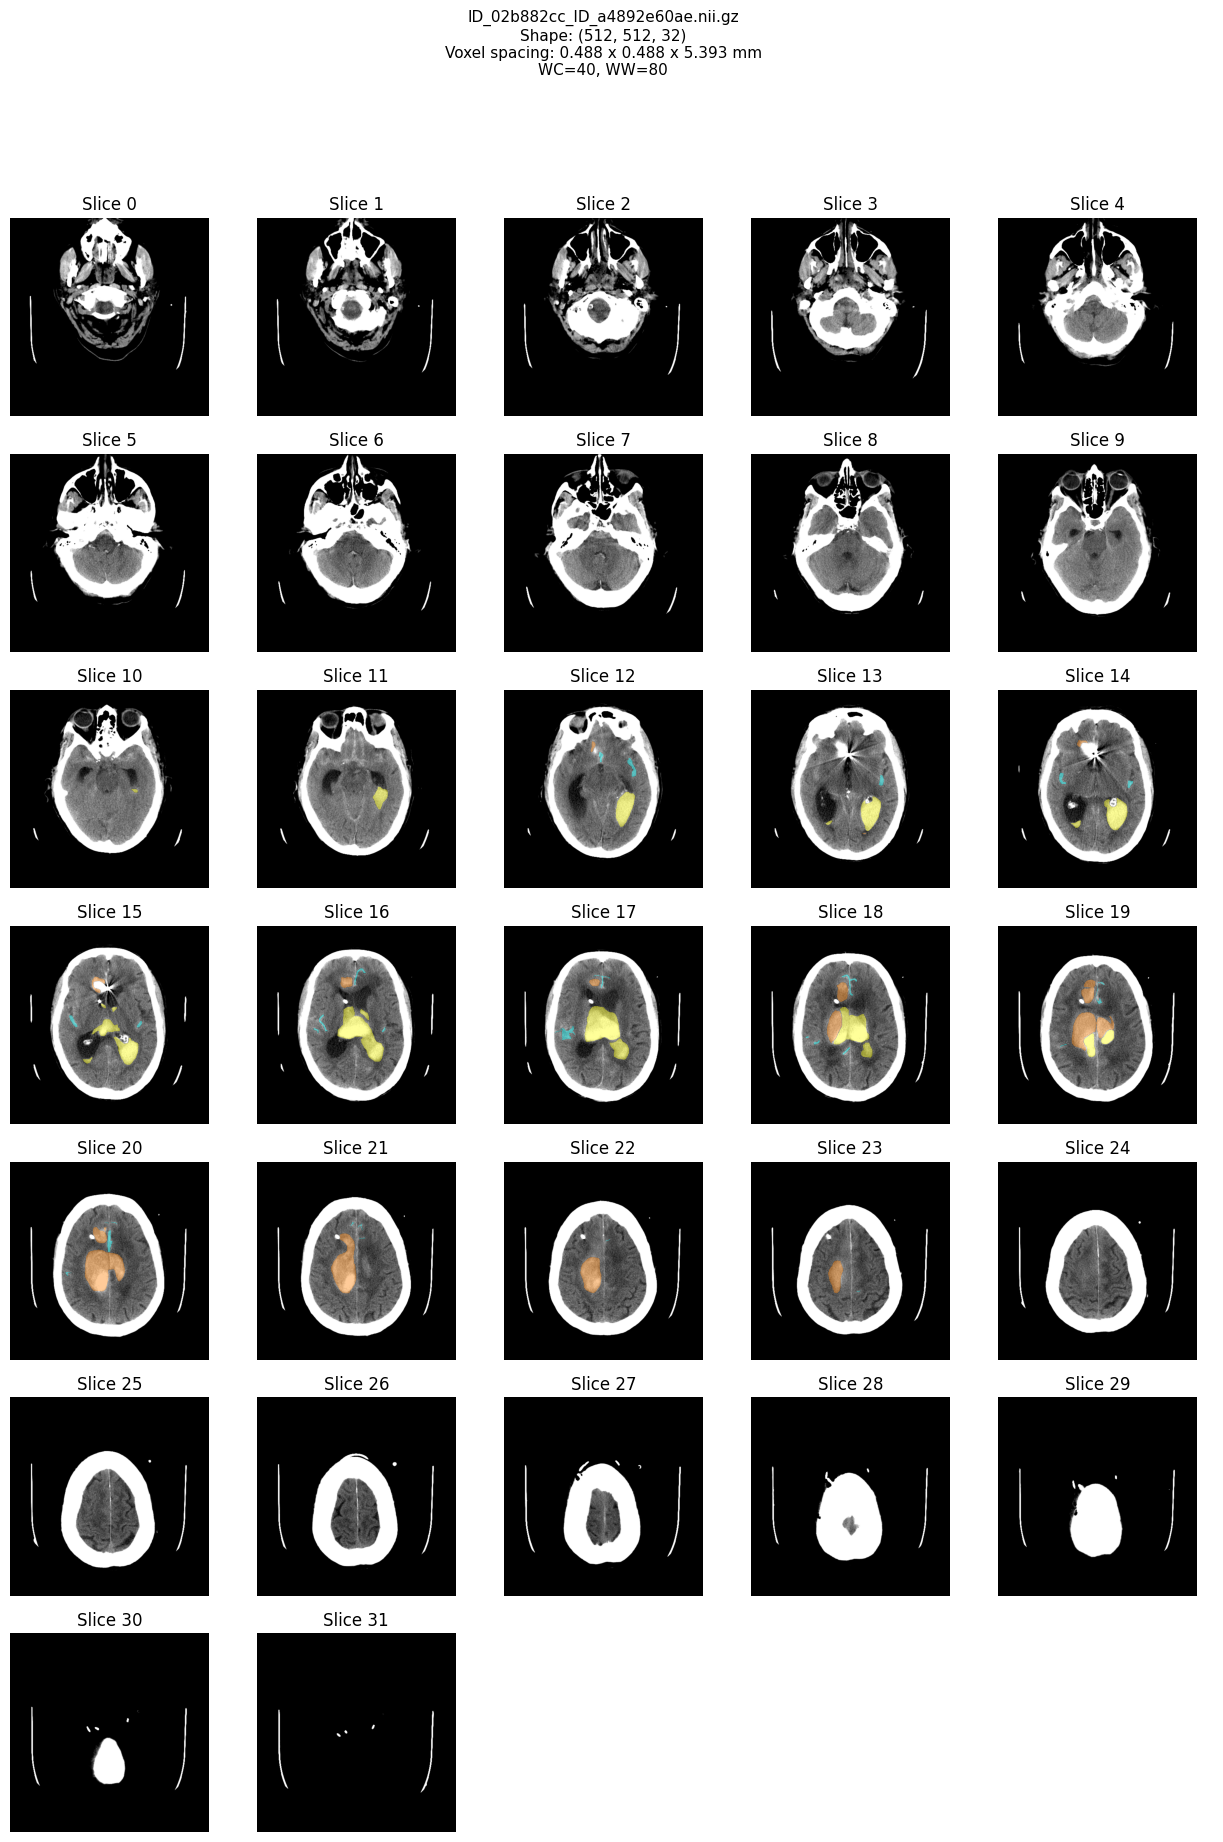

<Figure size 640x480 with 0 Axes>

In [50]:
show_all_slices(
        "ID_02b882cc_ID_a4892e60ae.nii.gz",
        window=(40, 80),
        overlay=True
    )